<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
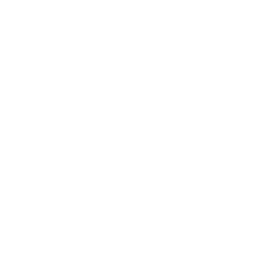
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Product Category Performance Panels</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Retail / Merchandising Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Executive Summary

A merchandising team needs a single visual brief comparing how six product categories perform across a 16-week selling season at a regional store cluster. We generate 96 weekly observations (6 categories x 16 weeks) and use **PROC SGPANEL** to build three paneled views keyed on `category`: a weekly revenue trend (VLINE), a realized-margin distribution (HISTOGRAM with kernel DENSITY), and a holiday-versus-regular revenue comparison (HBAR). We then feed the category totals into **PROC TABULATE** for a cross-tabulated revenue-and-margin report by season phase.

The panels surface a clear story. **Grocery** is the revenue leader at \$223,796 over the season but runs the thinnest realized margin (27.7%). **Beauty** is the opposite profile: the smallest revenue base (\$70,991) yet the richest realized margin (55.8%). Every category shows a pronounced holiday lift in the final four weeks, ranging from 1.48x (Beauty) to 1.69x (Grocery). The paneled layout makes these cross-category contrasts readable at a glance, which is exactly what SGPANEL is built for.

## Data Sources

| Source | Description | Records |
|--------|-------------|--------|
| WORK.CATEGORY_SALES | Weekly product category sales for a regional store cluster | 96 |

Each row is one category-week: revenue, gross margin, realized margin percent, a promotion flag, and a season phase (Regular for weeks 1-12, Holiday for weeks 13-16).

---

In [1]:
/* --------------------------------------------------------
   Generate weekly category sales for one regional cluster.
   6 categories x 16 weeks = 96 rows (within the demo cap).
   Weeks 13-16 carry a holiday lift; ~1 in 5 weeks runs a
   promotion that adds incremental revenue.
   -------------------------------------------------------- */
data work.category_sales;
    call streaminit(42);
    array cat_list[6] $12 _temporary_ (
        'Electronics' 'Apparel' 'Grocery'
        'HomeGarden' 'Beauty' 'Toys');
    array cat_margin[6] _temporary_ (
        0.22 0.48 0.28 0.38 0.55 0.42);
    array cat_base[6] _temporary_ (
        8500 5200 12000 4800 3800 2800);
    length category $12 phase $8;
    do c = 1 to 6;
        category   = cat_list[c];
        base_rev   = cat_base[c];
        margin_pct = cat_margin[c];
        do week_num = 1 to 16;
            week_start = '06JAN2026'd + (week_num - 1) * 7;
            if week_num >= 13 then do;
                seas  = 1.6;
                phase = 'Holiday';
            end;
            else do;
                seas  = 1.0;
                phase = 'Regular';
            end;
            promo_flag = (rand('uniform') < 0.20);
            promo_lift = ifn(promo_flag,
                1.0 + rand('uniform') * 0.4, 1.0);
            weekly_revenue = round(base_rev * seas * promo_lift
                * (0.85 + rand('uniform') * 0.3), 1);
            gross_margin = round(weekly_revenue * margin_pct
                * (0.92 + rand('uniform') * 0.16), 1);
            margin_realized =
                round(gross_margin / weekly_revenue * 100, 0.1);
            output;
        end;
    end;
    keep category week_num week_start weekly_revenue
         gross_margin margin_realized promo_flag phase;
    format week_start date9.
           weekly_revenue gross_margin comma8.;
run;

NOTE: DATA work.category_sales


NOTE: Wrote work.category_sales (96 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline revenue and margin by category. These category
   totals are what the panels below visualize.
   -------------------------------------------------------- */
proc means data=work.category_sales n sum mean maxdec=0;
    class category;
    var weekly_revenue gross_margin margin_realized;
run;

                                                  The MEANS Procedure

                                           Analysis Variable : WEEKLY_REVENUE

        CATEGORY             N Obs            Sum           Mean
        --------------------------------------------------------
        Apparel                 16         99,579          6,224
        Beauty                  16         70,991          4,437
        Electronics             16        157,771          9,861
        Grocery                 16        223,796         13,987
        HomeGarden              16         88,790          5,549
        Toys                    16         53,821          3,364
        --------------------------------------------------------

                                            Analysis Variable : GROSS_MARGIN

        CATEGORY             N Obs            Sum           Mean
        --------------------------------------------------------
        Apparel                 16         47,616       

NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


### Weekly revenue trend by category

`PANELBY category` lays the six categories out in a 3x2 grid; `VLINE week_num / response=weekly_revenue stat=mean` draws each category's weekly revenue path on a shared axis so the magnitudes are directly comparable.

PROC SGPANEL Output
Data: work.category_sales

Variables: category, week_num, week_start, weekly_revenue, gross_margin, margin_realized, promo_flag, phase

  category    week_num  week_start  weekly_revenue  gross_margin  margin_realized  promo_flag       phase
----------  ----------  ----------  --------------  ------------  ---------------  ----------  ----------
Electronics           1       24112            7508          1733             23.1           0     Regular
Electronics           2       24119            9165          1950             21.3           0     Regular
Electronics           3       24126            8230          1793             21.8           0     Regular
Electronics           4       24133           11292          2489               22           1     Regular
Electronics           5       24140            8012          1675             20.9           0     Regular
Electronics           6       24147            8438          1909             22.6           0   

NOTE: PROC SGPANEL data=work.category_sales

NOTE: PROC SGPANEL output written to: ./ods_output/sgpanel.svg


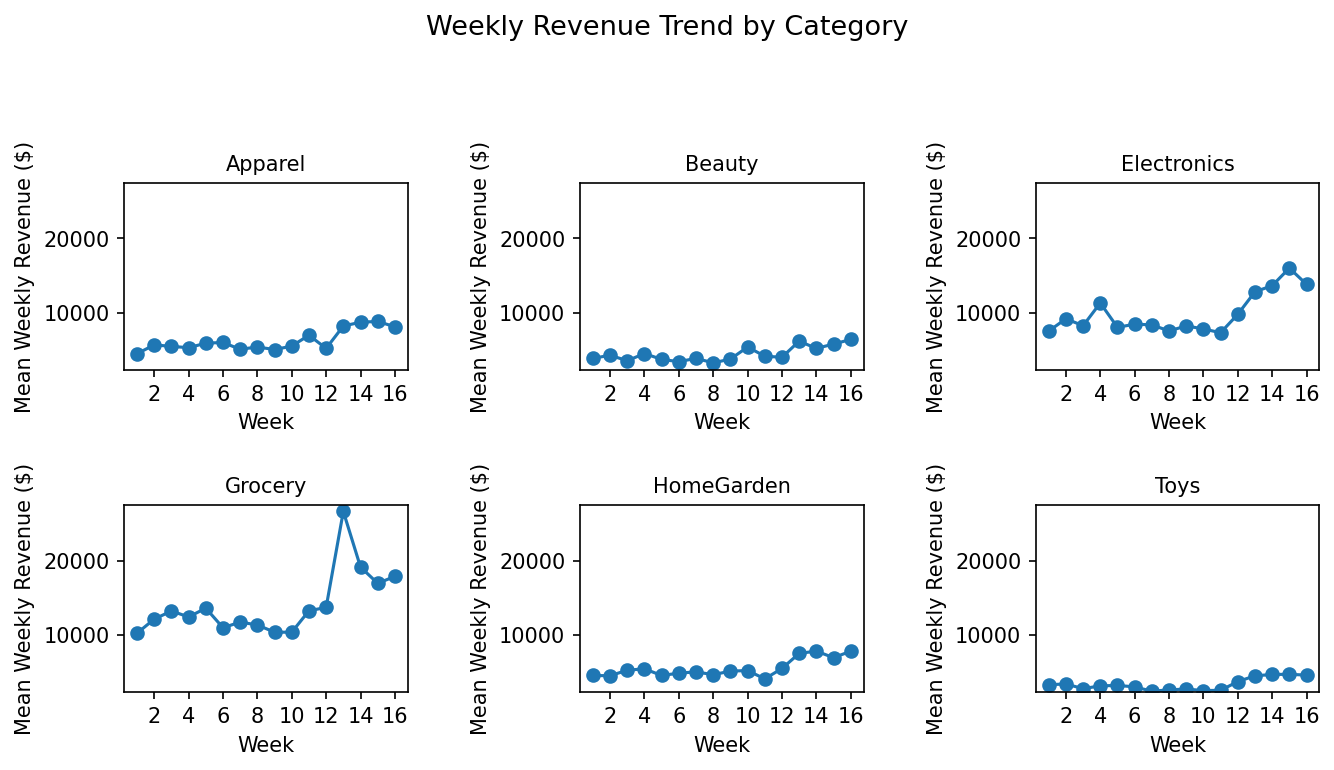

In [3]:
/* --------------------------------------------------------
   CHART 1 - Paneled weekly revenue trend (one line per
   category). Shared axes make cross-category magnitude and
   the late-season holiday spike easy to compare.
   -------------------------------------------------------- */
proc sgpanel data=work.category_sales;
    panelby category / columns=3 rows=2 layout=panel novarname;
    vline week_num / response=weekly_revenue stat=mean
        lineattrs=(thickness=2 color=steelblue)
        markers markerattrs=(symbol=circlefilled size=5);
    colaxis label='Week' integer;
    rowaxis label='Mean Weekly Revenue ($)';
    title 'Weekly Revenue Trend by Category';
run;

### Realized-margin distribution by category

The same panel layout with `HISTOGRAM margin_realized` plus a kernel `DENSITY` overlay shows where each category's weekly realized margin clusters. The shared x-axis ranks the categories by margin band.

PROC SGPANEL Output
Data: work.category_sales

Variables: category, week_num, week_start, weekly_revenue, gross_margin, margin_realized, promo_flag, phase

  category    week_num  week_start  weekly_revenue  gross_margin  margin_realized  promo_flag       phase
----------  ----------  ----------  --------------  ------------  ---------------  ----------  ----------
Electronics           1       24112            7508          1733             23.1           0     Regular
Electronics           2       24119            9165          1950             21.3           0     Regular
Electronics           3       24126            8230          1793             21.8           0     Regular
Electronics           4       24133           11292          2489               22           1     Regular
Electronics           5       24140            8012          1675             20.9           0     Regular
Electronics           6       24147            8438          1909             22.6           0   

NOTE: PROC SGPANEL data=work.category_sales

NOTE: PROC SGPANEL output written to: ./ods_output/sgpanel.svg


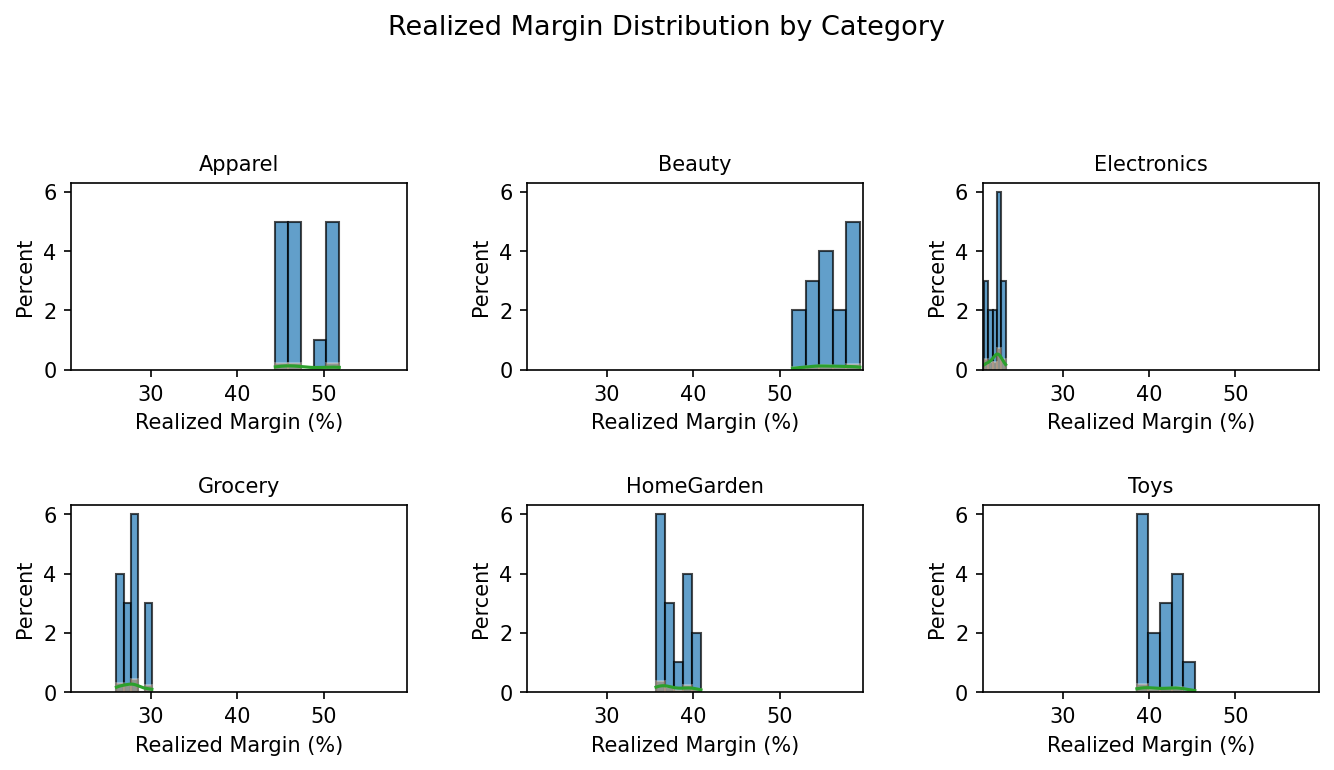

In [4]:
/* --------------------------------------------------------
   CHART 2 - Paneled realized-margin distribution with a
   kernel density overlay. Reveals each category's margin
   band on a shared scale.
   -------------------------------------------------------- */
proc sgpanel data=work.category_sales;
    panelby category / columns=3 rows=2 layout=panel novarname;
    histogram margin_realized /
        fillattrs=(color=cx2c7fb8 transparency=0.3);
    density margin_realized / type=kernel
        lineattrs=(color=navy thickness=2);
    colaxis label='Realized Margin (%)';
    rowaxis label='Percent';
    title 'Realized Margin Distribution by Category';
run;

PROC SGPANEL Output
Data: work.category_sales

Variables: category, week_num, week_start, weekly_revenue, gross_margin, margin_realized, promo_flag, phase

  category    week_num  week_start  weekly_revenue  gross_margin  margin_realized  promo_flag       phase
----------  ----------  ----------  --------------  ------------  ---------------  ----------  ----------
Electronics           1       24112            7508          1733             23.1           0     Regular
Electronics           2       24119            9165          1950             21.3           0     Regular
Electronics           3       24126            8230          1793             21.8           0     Regular
Electronics           4       24133           11292          2489               22           1     Regular
Electronics           5       24140            8012          1675             20.9           0     Regular
Electronics           6       24147            8438          1909             22.6           0   

NOTE: PROC SGPANEL data=work.category_sales

NOTE: PROC SGPANEL output written to: ./ods_output/sgpanel.svg


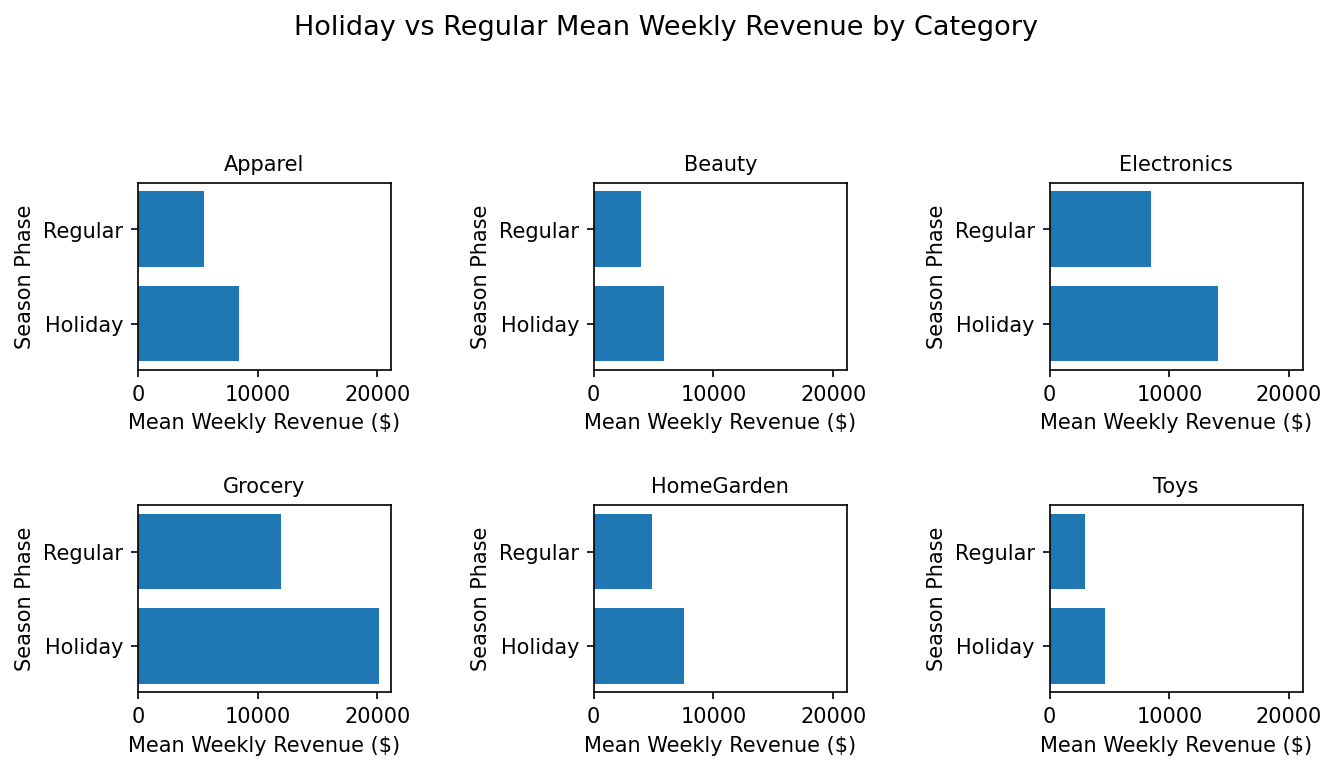

In [5]:
/* --------------------------------------------------------
   CHART 3 - Holiday vs Regular mean weekly revenue per
   category. Two bars per panel quantify the seasonal lift
   that Chart 1 shows qualitatively.
   -------------------------------------------------------- */
proc sgpanel data=work.category_sales;
    panelby category / columns=3 rows=2 layout=panel novarname;
    hbar phase / response=weekly_revenue stat=mean
        fillattrs=(color=teal transparency=0.2)
        datalabel datalabelattrs=(size=7);
    colaxis label='Mean Weekly Revenue ($)';
    rowaxis label='Season Phase';
    title 'Holiday vs Regular Mean Weekly Revenue by Category';
run;

In [6]:
/* --------------------------------------------------------
   Cross-tabulated executive report: revenue and gross
   margin by category and season phase, with row and column
   totals.
   -------------------------------------------------------- */
proc tabulate data=work.category_sales format=comma10.;
    class category phase;
    var weekly_revenue gross_margin;
    table category all='Total',
          (phase all='Total')
            * (weekly_revenue='Revenue' * sum=' '
               gross_margin='Margin' * sum=' ')
        / box='Category';
    title 'Revenue and Margin by Category and Season Phase';
run;

----------------------------------------------------------------------
|Category   |                PHASE                |                  |
|           |-------------------------------------|                  |
|           |     Holiday      |     Regular      |      Total       |
|           |------------------+------------------+------------------|
|           | Revenue | Margin | Revenue | Margin | Revenue | Margin |
|-----------+---------+--------+---------+--------+---------+--------|
|CATEGORY   |         |        |         |        |         |        |
|-----------|         |        |         |        |         |        |
|Apparel    |   33,789|  15,872|   65,790|  31,744|   99,579|  47,616|
|-----------+---------+--------+---------+--------+---------+--------|
|Beauty     |   23,483|  13,136|   47,508|  26,503|   70,991|  39,639|
|-----------+---------+--------+---------+--------+---------+--------|
|Electronics|   56,193|  12,502|  101,578|  22,572|  157,771|  35,074|
|-----

NOTE: PROC TABULATE


In [7]:
/* --------------------------------------------------------
   Roll the weekly rows up to one row per category for the
   executive summary export.
   -------------------------------------------------------- */
proc means data=work.category_sales noprint;
    class category;
    var weekly_revenue gross_margin margin_realized promo_flag;
    output out=work.cat_summary(where=(_type_ = 1))
        sum(weekly_revenue)=total_revenue
        sum(gross_margin)=total_margin
        mean(weekly_revenue)=avg_weekly_revenue
        mean(margin_realized)=avg_margin_pct
        mean(promo_flag)=promo_rate;
run;

proc print data=work.cat_summary noobs label;
    var category total_revenue total_margin
        avg_weekly_revenue avg_margin_pct promo_rate;
    format total_revenue total_margin comma10.
           avg_weekly_revenue comma8.
           avg_margin_pct 5.1 promo_rate percent6.1;
    label category='Category'
          total_revenue='Total Revenue'
          total_margin='Total Margin'
          avg_weekly_revenue='Avg Weekly Rev'
          avg_margin_pct='Avg Margin %'
          promo_rate='Promo Rate';
    title 'Category Performance Summary';
run;

                                              Category Performance Summary                                              

   Category  Total Revenue  Total Margin  Avg Weekly Rev  Avg Margin %  Promo Rate
Apparel             99,579        47,616           6,224          47.9        6.2%
Beauty              70,991        39,639           4,437          55.8       18.8%
Electronics        157,771        35,074           9,861          22.2       12.5%
Grocery            223,796        61,922          13,987          27.7       12.5%
HomeGarden          88,790        33,563           5,549          37.8       18.8%
Toys                53,821        22,406           3,364          41.5       37.5%



NOTE: PROC MEANS
NOTE: Output dataset work.cat_summary has 6 observations and 8 variables.
NOTE: PROC MEANS statement used.
NOTE: PROC PRINT data=work.cat_summary

NOTE: PROC PRINT completed: 6 observations printed, 6 variables


---

### Interpretation

The three panels read together as a category scorecard.

**Revenue trend (Chart 1).** Every category's weekly revenue is roughly flat through week 12 and then steps up in the final four weeks. Grocery is the clear volume leader, peaking near \$26,600 in a promoted holiday week, while Toys sits at the bottom of the range throughout. The shared y-axis lets you compare absolute scale across panels, not just shape.

**Margin distribution (Chart 2).** The categories separate into distinct margin bands. Electronics clusters tightest and lowest, around 22%; Grocery sits near 28%; HomeGarden near 38%; Toys near 42%; Apparel near 48%; and Beauty highest, around 56%. The mean realized margins from PROC MEANS confirm this ordering exactly (Beauty 55.8% highest, Electronics 22.2% lowest).

**Holiday lift (Chart 3).** Holiday weeks beat regular weeks in every category. Mean weekly revenue rises from \$11,938 to \$20,134 in Grocery (1.69x) and from \$8,465 to \$14,048 in Electronics (1.66x); the smallest lift is Beauty at 1.48x. Because each panel shares the same axis, the size of each category's seasonal bump is directly comparable.

**Executive cross-tab.** PROC TABULATE confirms the totals: Grocery leads full-period revenue at \$223,796 but contributes \$61,922 in margin, while Apparel turns a far smaller \$99,579 revenue base into \$47,616 of margin. Across all six categories the season produced \$694,748 in revenue and \$240,220 in gross margin.

---

In [8]:
/* --------------------------------------------------------
   Export the category performance summary for the
   merchandising review.
   -------------------------------------------------------- */
proc export data=work.cat_summary
    outfile='category_performance.csv'
    dbms=csv replace;
run;

NOTE: PROC EXPORT data=work.cat_summary outfile=category_performance.csv

NOTE: Exported 6 rows to category_performance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>